In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n = 240

df = pd.DataFrame({
    "shipment_date": pd.date_range("2025-01-01", periods=n),
    "region": np.random.choice(
        ["North", "South", "East", "West"], n
    ),
    "transport_mode": np.random.choice(
        ["Road", "Rail", "Air"], n,
        p=[0.55, 0.25, 0.20]
    ),
    "shipment_volume": np.random.randint(100, 1000, n),
    "distance_km": np.random.randint(50, 1500, n)
})

df["delivery_time_days"] = (
    df["distance_km"] / 300 +
    df["shipment_volume"] / 500 +
    np.random.normal(1, 0.5, n)
).round(2)

df["delivery_delay_days"] = np.maximum(
    0,
    df["delivery_time_days"] - 4
).round(2)

df["transport_cost"] = (
    df["distance_km"] * 2 +
    df["shipment_volume"] * 0.5 +
    np.random.normal(0, 100, n)
).round(2)

df["customer_satisfaction"] = np.clip(
    5 - df["delivery_delay_days"] * 0.5 +
    np.random.normal(0, 0.3, n),
    1, 5
).round(1)

df["delivery_status"] = np.where(
    df["delivery_delay_days"] == 0,
    "On Time",
    "Delayed"
)

df.head()

,shipment_date,region,transport_mode,shipment_volume,distance_km,delivery_time_days,delivery_delay_days,transport_cost,customer_satisfaction,delivery_status
0,2025-01-01,East,Air,789,1421,8.36,4.36,3226.61,3.0,Delayed
1,2025-01-02,West,Air,774,725,5.66,1.66,2066.80,3.9,Delayed
2,2025-01-03,North,Road,479,139,1.42,0.00,636.12,5.0,On Time
3,2025-01-04,East,Road,644,747,5.31,1.31,1841.71,4.4,Delayed
4,2025-01-05,East,Road,790,1389,7.57,3.57,3313.39,3.7,Delayed


In [ ]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (240, 10)

Data Types:
shipment_date            datetime64[ns]
region                           object
transport_mode                   object
shipment_volume                   int64
distance_km                       int64
delivery_time_days              float64
delivery_delay_days             float64
transport_cost                  float64
customer_satisfaction           float64
delivery_status                  object
dtype: object

Missing Values:
shipment_date            0
region                   0
transport_mode           0
shipment_volume          0
distance_km              0
delivery_time_days       0
delivery_delay_days      0
transport_cost           0
customer_satisfaction    0
delivery_status          0
dtype: int64

Duplicate Rows:
0

Statistical Summary:


,shipment_date,shipment_volume,distance_km,delivery_time_days,delivery_delay_days,transport_cost,customer_satisfaction
count,240,240.00000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,2025-04-30 12:00:00,539.28750,731.820833,4.559833,0.989667,1745.238500,4.480000
min,2025-01-01 00:00:00,100.00000,50.000000,0.670000,0.000000,142.070000,2.700000
25%,2025-03-01 18:00:00,300.25000,326.750000,3.242500,0.000000,994.270000,4.100000
50%,2025-04-30 12:00:00,520.00000,764.500000,4.565000,0.565000,1783.155000,4.600000
75%,2025-06-29 06:00:00,762.25000,1082.000000,5.770000,1.770000,2486.597500,5.000000
max,2025-08-28 00:00:00,997.00000,1495.000000,8.720000,4.720000,3554.240000,5.000000
std,NaN,261.27141,425.523381,1.628870,1.131855,866.922893,0.551696


In [ ]:
numeric_columns = [
    "shipment_volume",
    "distance_km",
    "delivery_time_days",
    "delivery_delay_days",
    "transport_cost",
    "customer_satisfaction"
]

summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Standard Deviation": df[numeric_columns].std()
})

summary.round(2)

,Mean,Median,Standard Deviation
shipment_volume,539.29,520.00,261.27
distance_km,731.82,764.50,425.52
delivery_time_days,4.56,4.56,1.63
delivery_delay_days,0.99,0.56,1.13
transport_cost,1745.24,1783.16,866.92
customer_satisfaction,4.48,4.60,0.55


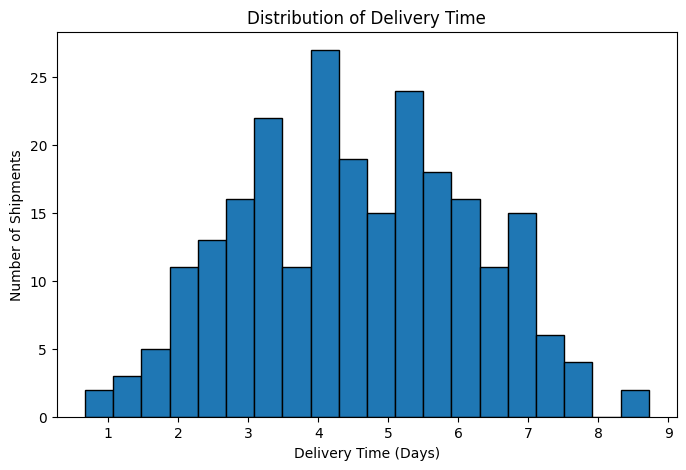

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["delivery_time_days"], bins=20, edgecolor="black")

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Shipments")

plt.show()

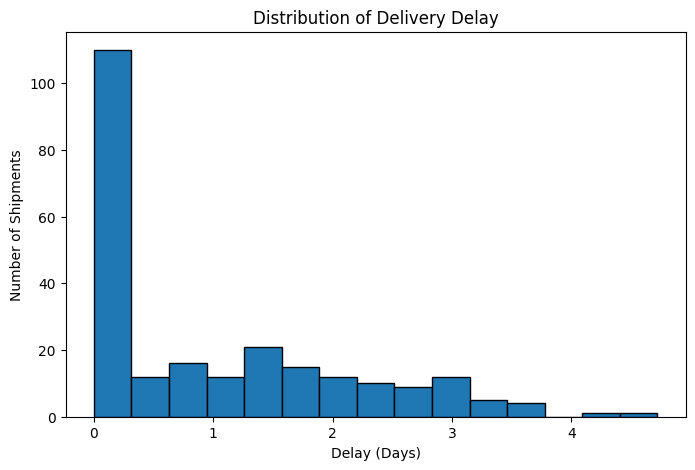

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["delivery_delay_days"], bins=15, edgecolor="black")

plt.title("Distribution of Delivery Delay")
plt.xlabel("Delay (Days)")
plt.ylabel("Number of Shipments")

plt.show()

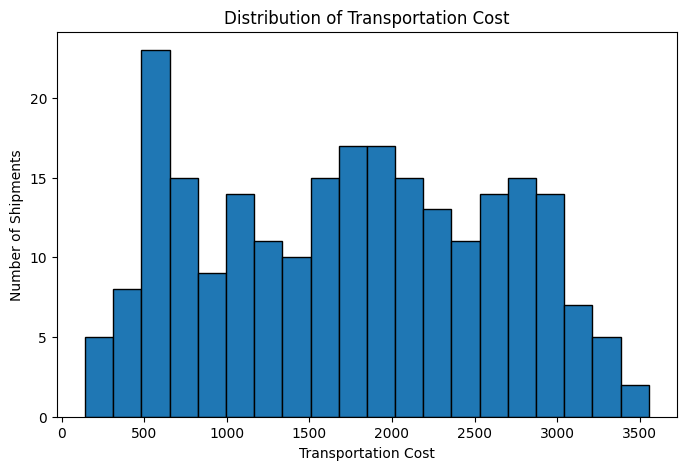

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["transport_cost"], bins=20, edgecolor="black")

plt.title("Distribution of Transportation Cost")
plt.xlabel("Transportation Cost")
plt.ylabel("Number of Shipments")

plt.show()

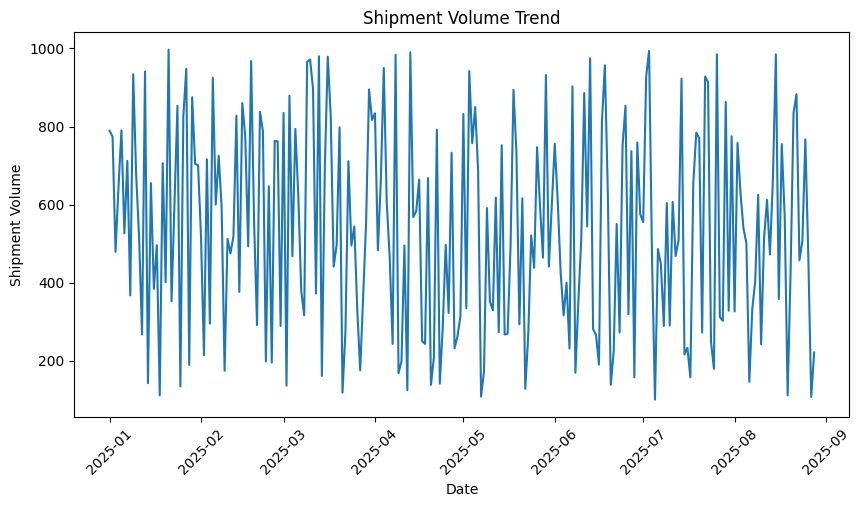

In [ ]:
daily_volume = df.groupby(
    "shipment_date"
)["shipment_volume"].sum()

plt.figure(figsize=(10,5))

plt.plot(daily_volume)

plt.title("Shipment Volume Trend")
plt.xlabel("Date")
plt.ylabel("Shipment Volume")

plt.xticks(rotation=45)

plt.show()

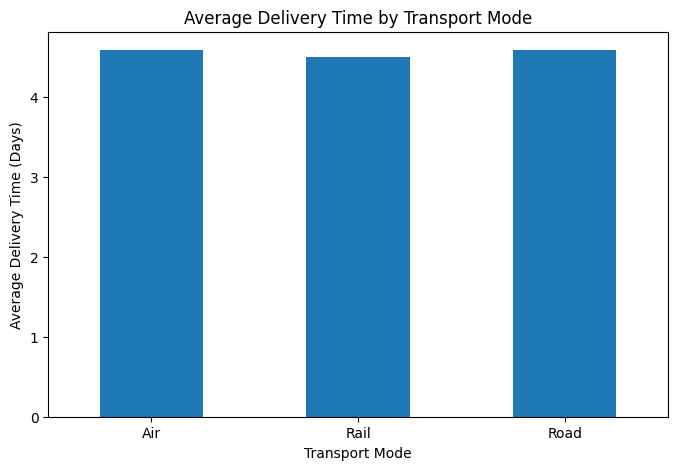

In [ ]:
avg_delivery = df.groupby(
    "transport_mode"
)["delivery_time_days"].mean()

plt.figure(figsize=(8,5))

avg_delivery.plot(kind="bar")

plt.title("Average Delivery Time by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Average Delivery Time (Days)")

plt.xticks(rotation=0)

plt.show()

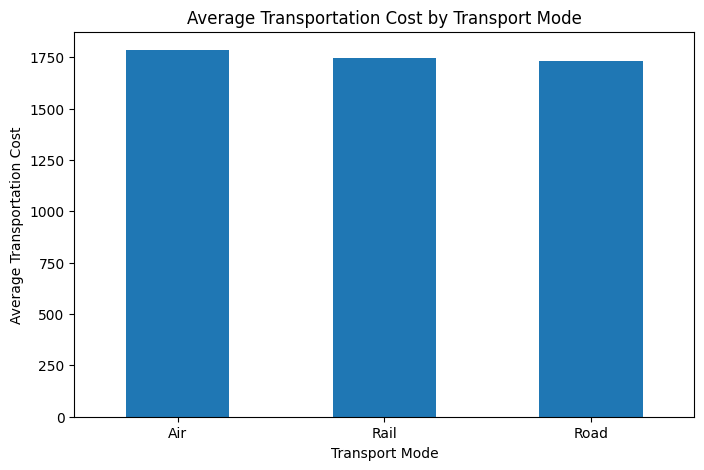

In [ ]:
avg_cost = df.groupby(
    "transport_mode"
)["transport_cost"].mean()

plt.figure(figsize=(8,5))

avg_cost.plot(kind="bar")

plt.title("Average Transportation Cost by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Average Transportation Cost")

plt.xticks(rotation=0)

plt.show()

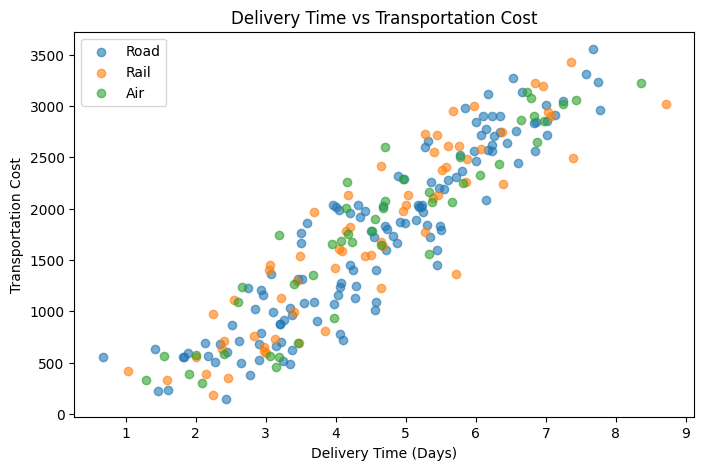

In [ ]:
plt.figure(figsize=(8,5))

for mode in ["Road", "Rail", "Air"]:

    data = df[df["transport_mode"] == mode]

    plt.scatter(
        data["delivery_time_days"],
        data["transport_cost"],
        label=mode,
        alpha=0.6
    )

plt.title("Delivery Time vs Transportation Cost")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Transportation Cost")

plt.legend()

plt.show()

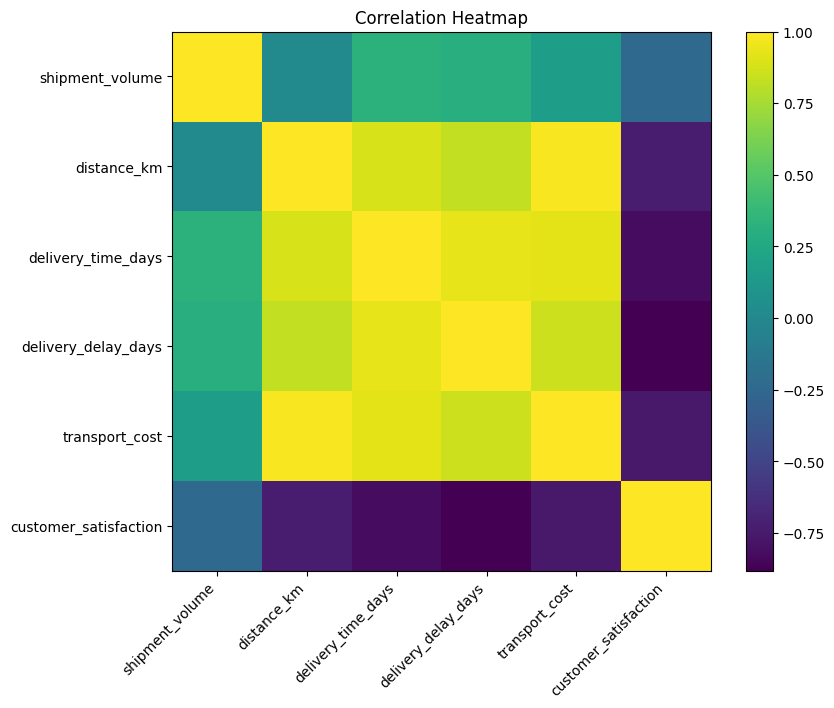

In [ ]:
correlation = df[numeric_columns].corr()

correlation.round(2)
plt.figure(figsize=(9,7))

plt.imshow(correlation, interpolation="nearest")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
regional_analysis = df.groupby("region").agg({
    "shipment_volume": "mean",
    "delivery_time_days": "mean",
    "delivery_delay_days": "mean",
    "transport_cost": "mean",
    "customer_satisfaction": "mean"
}).round(2)

regional_analysis

,shipment_volume,delivery_time_days,delivery_delay_days,transport_cost,customer_satisfaction
region,,,,,
East,553.52,4.79,1.20,1861.06,4.41
North,530.65,4.49,0.88,1744.96,4.50
South,566.54,4.26,0.80,1646.31,4.59
West,510.82,4.64,1.03,1714.56,4.44


**Key Analytical Insights:**

Delivery-time distribution helps understand normal delivery performance.

Delivery delays can identify potential operational bottlenecks.

Shipment-volume trends can support capacity planning.
Transport modes show differences in delivery time and transportation cost.

Distance and shipment volume can contribute to transportation costs.

Correlation analysis helps identify relationships between logistics metrics.

Regional analysis can help identify areas requiring further investigation.

Important: Because this is a hypothetical dataset, these findings are for analytical practice and should not be treated as real-world measurements.



**Recommendations**

Monitor delivery delays regularly using logistics KPIs.

Use shipment-volume trends for capacity planning.
Compare transport modes using both cost and delivery performance.

Investigate high-distance shipments separately.
Monitor transportation costs by region and transport mode.

Build a logistics dashboard for continuous KPI monitoring.

Validate these findings using real operational data before making business decisions.



In [ ]:
df.to_csv(
    "hypothetical_logistics_dataset.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!
